<a href="https://colab.research.google.com/github/modeloteoriadecolas/TEORIA-DE-COLAS.ipynb/blob/main/TEORIA_DE_COLAS.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

import os

# Ver la raíz de tu Drive
print("=== CONTENIDO DE MyDrive ===")
for item in os.listdir('/content/drive/MyDrive'):
    print("📁", item)

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
=== CONTENIDO DE MyDrive ===
📁 Colab Notebooks
📁 How to get started with Drive.pdf
📁 Classroom
📁 tesis
📁 ANÁLISIS DE DATOS COPIA TESIS.xlsx
📁 SALIDA SOLUCIONADA.drawio


In [ ]:
for palabra in ["TESIS", "COPIA", "DATOS"]:
    print(f"\n--- Buscando '{palabra}' ---")
    for root, dirs, files in os.walk('/content/drive/MyDrive'):
        for f in files:
            if palabra in f.upper() and f.endswith(('.xlsx', '.xls')):
                print("✅", os.path.join(root, f))


--- Buscando 'TESIS' ---
✅ /content/drive/MyDrive/ANÁLISIS DE DATOS COPIA TESIS.xlsx

--- Buscando 'COPIA' ---
✅ /content/drive/MyDrive/ANÁLISIS DE DATOS COPIA TESIS.xlsx

--- Buscando 'DATOS' ---
✅ /content/drive/MyDrive/ANÁLISIS DE DATOS COPIA TESIS.xlsx


In [ ]:
RUTA = '/content/drive/MyDrive/ANÁLISIS DE DATOS COPIA TESIS.xlsx'

import os
print("¿Existe?", os.path.exists(RUTA))

¿Existe? True


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import math

RUTA = '/content/drive/MyDrive/ANÁLISIS DE DATOS COPIA TESIS.xlsx'  # tu ruta

exp     = pd.read_excel(RUTA, sheet_name='EXP')
imp     = pd.read_excel(RUTA, sheet_name='IMP')
exp_tc  = pd.read_excel(RUTA, sheet_name='EXP TC')
imp_tc  = pd.read_excel(RUTA, sheet_name='IMP TC')
madre   = pd.read_excel(RUTA, sheet_name='DATOS MADRE')

print("EXP     :", exp.shape)
print("IMP     :", imp.shape)
print("EXP TC  :", exp_tc.shape)
print("IMP TC  :", imp_tc.shape)
print("MADRE   :", madre.shape)

EXP     : (162, 18)
IMP     : (114, 18)
EXP TC  : (153, 21)
IMP TC  : (106, 21)
MADRE   : (259, 14)


In [ ]:
print("Columnas EXP:")
print(exp.columns.tolist())
print("\nPrimeras filas:")
exp.head(3)

Columnas EXP:
['Fecha', 'Placa', 'Tipo de carga', 'Proceso ', 'Origen', 'Destino', 'T. Llegada', 'Aduanas', 'Migración', 'MIDA', 'Delay', 'T. Servicio', 'T. Salida', 'T. Sistema', 'Observación', 'Unnamed: 15', 'T. Llegada.1', 'T. Sistema.1']

Primeras filas:


,Fecha,Placa,Tipo de carga,Proceso,Origen,Destino,T. Llegada,Aduanas,Migración,MIDA,Delay,T. Servicio,T. Salida,T. Sistema,Observación,Unnamed: 15,T. Llegada.1,T. Sistema.1
0,2025-02-07 00:00:00,C170665,vacío,exportación,Panamá,Costa Rica,15:35:23,00:04:02.290000,00:03:28,00:00:00,00:00:00,00:07:30.290000,15:42:53.290000,00:07:30.290000,NaN,NaN,15:35:23,00:07:30.290000
1,2025-02-07 00:00:00,C124943,vacío,exportación,Panamá,Costa Rica,15:36:14,00:08:15.270000,00:04:17.870000,00:00:00,00:00:00,00:12:33.140000,15:48:47.140000,00:12:33.140000,NaN,1.0,15:36:14,00:12:33.140000
2,2025-02-07 00:00:00,C125957,vacío,exportación,Panamá,Costa Rica,15:37:02,00:05:33.760000,00:08:19.850000,00:00:00,00:12:41.120000,00:26:34.730000,16:03:36.730000,00:26:34.730000,Multa ATT,NaN,15:37:02,00:26:34.730000


In [ ]:
print("Columnas IMP:")
print(imp.columns.tolist())
imp.head(3)

Columnas IMP:
['Fecha', 'Placa', 'Tipo de carga', 'Proceso ', 'Origen', 'Destino', 'T. Llegada', 'Aduanas', 'Migración', 'MIDA', 'Delay', 'T. Servicio', 'T. Salida', 'T. Sistema', 'Observación', 'Unnamed: 15', 'T. Llegada.1', 'T. Sistema.1']


,Fecha,Placa,Tipo de carga,Proceso,Origen,Destino,T. Llegada,Aduanas,Migración,MIDA,Delay,T. Servicio,T. Salida,T. Sistema,Observación,Unnamed: 15,T. Llegada.1,T. Sistema.1
0,2025-02-07 00:00:00,EU9130,vacío,importación,Costa Rica,Panamá,15:50:30,00:08:15.270000,00:04:17.870000,00:01:42.560000,00:00:00,00:14:15.700000,16:04:45.700000,00:14:15.700000,NaN,NaN,15:50:30,00:14:15.700000
1,2025-02-07 00:00:00,S29165,vacío,importación,Costa Rica,Panamá,16:11:10,00:03:27.660000,00:04:02.290000,00:04:18.930000,00:00:00,00:11:48.880000,16:22:58.880000,00:11:48.880000,NaN,NaN,16:11:10,00:11:48.880000
2,2025-02-07 00:00:00,471625,vacío,importación,Costa Rica,Panamá,16:13:15,00:08:19.850000,00:05:33.760000,00:01:19.470000,00:05:14.210000,00:20:27.290000,16:33:42.290000,00:20:27.290000,NaN,NaN,16:13:15,00:20:27.290000


In [ ]:
def limpiar_hoja(df, nombre):
    df = df.copy()
    # Fecha debe ser una fecha real
    df['Fecha_dt'] = pd.to_datetime(df['Fecha'], errors='coerce')
    df = df[df['Fecha_dt'].notna()]
    # Placa debe existir y no ser "ASPECTOS ESTADÍSTICOS"
    df = df[df['Placa'].notna()]
    df = df[~df['Placa'].astype(str).str.contains('ASPECTOS', case=False, na=False)]
    df = df.reset_index(drop=True)
    print(f"{nombre}: {df.shape[0]} registros válidos")
    return df

exp_clean = limpiar_hoja(exp, "EXP")
imp_clean = limpiar_hoja(imp, "IMP")

EXP: 153 registros válidos
IMP: 106 registros válidos


In [ ]:
import numpy as np
from datetime import time as dt_time

def td_a_minutos_inteligente(serie):
    """
    Interpreta correctamente según el patrón del valor:
    - Si MM y SS son 0 y HH > 0 → HH eran minutos (error Excel)
    - En otro caso → formato normal HH:MM:SS
    """
    def convertir(x):
        if pd.isna(x):
            return np.nan
        if isinstance(x, dt_time):
            # Caso 1: HH:00:00 exacto → HH son MINUTOS
            if x.minute == 0 and x.second == 0 and x.microsecond == 0:
                return float(x.hour)
            # Caso 2: formato normal HH:MM:SS → convertir a minutos
            return (x.hour * 60 + x.minute + x.second / 60
                    + x.microsecond / 60_000_000)
        if isinstance(x, pd.Timedelta):
            return x.total_seconds() / 60
        try:
            return pd.to_timedelta(str(x)).total_seconds() / 60
        except Exception:
            return np.nan
    return serie.apply(convertir)


# Aplicar a TODAS las columnas con la MISMA función
for df, nombre in [(exp_clean, 'EXP'), (imp_clean, 'IMP')]:
    for col in ['Aduanas', 'Migración', 'MIDA', 'Delay']:
        df[col + '_min'] = td_a_minutos_inteligente(df[col])
    df['T_Servicio_min'] = (
        df['Aduanas_min'].fillna(0) +
        df['Migración_min'].fillna(0) +
        df['MIDA_min'].fillna(0) +
        df['Delay_min'].fillna(0)
    )
    print(f"{nombre} ✅")

EXP ✅
IMP ✅


In [ ]:
muestra = exp_clean[['Aduanas','Aduanas_min','MIDA','MIDA_min','Delay','Delay_min']].head(15)
print(muestra)

            Aduanas  Aduanas_min             MIDA  MIDA_min            Delay  \
0   00:04:02.290000     4.038167         00:00:00  0.000000         00:00:00   
1   00:08:15.270000     8.254500         00:00:00  0.000000         00:00:00   
2   00:05:33.760000     5.562667         00:00:00  0.000000  00:12:41.120000   
3   00:03:44.350000     3.739167  00:04:18.930000  4.315500         00:00:00   
4   00:03:30.500000     3.508333  00:02:33.010000  2.550167         00:00:00   
5   00:02:48.230000     2.803833  00:03:12.180000  3.203000  00:22:46.710000   
6   00:05:45.310000     5.755167  00:02:27.840000  2.464000         01:00:00   
7   00:02:06.480000     2.108000  00:03:59.120000  3.985333         02:00:00   
8   00:01:01.540000     1.025667  00:04:33.600000  4.560000         03:00:00   
9   00:01:55.850000     1.930833         00:01:51  1.850000         04:00:00   
10  00:03:31.500000     3.525000  00:02:02.330000  2.038833         05:00:00   
11  00:02:13.230000     2.220500  00:03:

In [ ]:
print("=== EXP (final) ===")
print(exp_clean[['Aduanas_min','Migración_min','MIDA_min','Delay_min','T_Servicio_min']].describe().round(2))

print("\n=== IMP (final) ===")
print(imp_clean[['Aduanas_min','Migración_min','MIDA_min','Delay_min','T_Servicio_min']].describe().round(2))

=== EXP (final) ===
       Aduanas_min  Migración_min  MIDA_min  Delay_min  T_Servicio_min
count       153.00         153.00    128.00     124.00          153.00
mean          3.27           3.30      8.77      11.58           23.30
std           1.50           1.63      6.42      16.99           18.09
min           0.79           0.78      0.00       0.00            5.31
25%           2.19           2.29      3.00       2.98           11.84
50%           3.00           2.97      8.00       8.00           19.77
75%           3.99           3.81     14.00      14.00           27.44
max          10.12          10.05     23.00     138.24          151.47

=== IMP (final) ===
       Aduanas_min  Migración_min  MIDA_min  Delay_min  T_Servicio_min
count       106.00         106.00     69.00      87.00          106.00
mean          2.58           2.48      3.71       6.42           12.74
std           2.26           1.03      4.97       6.76            8.84
min           0.26           0.90   

In [ ]:
def calcular_parametros(df, nombre, horas_por_dia=8):
    t_serv = df['T_Servicio_min'].mean()
    mu = 60 / t_serv
    n_dias = df['Fecha_dt'].dt.date.nunique()
    lam = len(df) / (n_dias * horas_por_dia)

    print(f"\n{'='*55}")
    print(f"  {nombre}")
    print(f"{'='*55}")
    print(f"Días observados        : {n_dias}")
    print(f"Camiones totales       : {len(df)}")
    print(f"T. servicio promedio   : {t_serv:.2f} min")
    print(f"λ (llegadas)           : {lam:.3f} camiones/hora")
    print(f"μ (servicio)           : {mu:.3f} camiones/hora")
    print(f"ρ con 1 servidor       : {lam/mu:.2%}")
    return lam, mu, t_serv

lam_exp, mu_exp, ts_exp = calcular_parametros(exp_clean, "EXPORTACIÓN")
lam_imp, mu_imp, ts_imp = calcular_parametros(imp_clean, "IMPORTACIÓN")


  EXPORTACIÓN
Días observados        : 6
Camiones totales       : 153
T. servicio promedio   : 23.30 min
λ (llegadas)           : 3.188 camiones/hora
μ (servicio)           : 2.576 camiones/hora
ρ con 1 servidor       : 123.76%

  IMPORTACIÓN
Días observados        : 5
Camiones totales       : 106
T. servicio promedio   : 12.74 min
λ (llegadas)           : 2.650 camiones/hora
μ (servicio)           : 4.708 camiones/hora
ρ con 1 servidor       : 56.29%


In [ ]:
def calcular_horas_reales(df):
    """Suma las horas operativas reales entre primera y última llegada por día."""
    df['Fecha_dt'] = pd.to_datetime(df['Fecha'], errors='coerce')
    df['hora_llegada'] = pd.to_datetime(df['T. Llegada'].astype(str),
                                         format='%H:%M:%S', errors='coerce')
    horas_por_dia = df.groupby(df['Fecha_dt'].dt.date)['hora_llegada'].agg(
        lambda x: (x.max() - x.min()).total_seconds() / 3600
    )
    return horas_por_dia

horas_exp = calcular_horas_reales(exp_clean)
print("Horas operativas por día (EXP):")
print(horas_exp)
print(f"Promedio: {horas_exp.mean():.2f} horas/día")

Horas operativas por día (EXP):
Fecha_dt
2025-02-07    2.055833
2025-05-07    1.178333
2025-07-07    2.201667
2025-09-07    2.583333
2025-10-07    3.309167
2025-12-07    3.826667
Name: hora_llegada, dtype: float64
Promedio: 2.53 horas/día


In [ ]:
# Opción más precisa: calcular horas reales por día
def calcular_horas_reales(df):
    """Suma las horas operativas reales entre primera y última llegada por día."""
    df['Fecha_dt'] = pd.to_datetime(df['Fecha'], errors='coerce')
    df['hora_llegada'] = pd.to_datetime(df['T. Llegada'].astype(str),
                                         format='%H:%M:%S', errors='coerce')
    horas_por_dia = df.groupby(df['Fecha_dt'].dt.date)['hora_llegada'].agg(
        lambda x: (x.max() - x.min()).total_seconds() / 3600
    )
    return horas_por_dia

horas_exp = calcular_horas_reales(exp_clean)
print("Horas operativas por día (EXP):")
print(horas_exp)
print(f"Promedio: {horas_exp.mean():.2f} horas/día")

Horas operativas por día (EXP):
Fecha_dt
2025-02-07    2.055833
2025-05-07    1.178333
2025-07-07    2.201667
2025-09-07    2.583333
2025-10-07    3.309167
2025-12-07    3.826667
Name: hora_llegada, dtype: float64
Promedio: 2.53 horas/día


In [ ]:
import math

def metricas_mmc(lam, mu, c):
    """Modelo M/M/c: llegadas Poisson, servicio exponencial, c servidores."""
    rho = lam / (c * mu)
    if rho >= 1:
        return {"rho": rho, "estable": False}

    suma = sum((lam/mu)**n / math.factorial(n) for n in range(c))
    ultimo = (lam/mu)**c / (math.factorial(c) * (1 - rho))
    P0 = 1 / (suma + ultimo)
    Pw = ultimo * P0

    Lq = Pw * rho / (1 - rho)
    L  = Lq + lam/mu
    Wq = Lq / lam
    W  = Wq + 1/mu

    return {
        "rho": rho, "P0": P0, "Pw": Pw,
        "Lq": Lq, "L": L, "Wq (min)": Wq*60, "W (min)": W*60,
        "estable": True
    }


def analizar_escenarios(lam, mu, nombre, carriles=[1,2,3,4,5,6]):
    print(f"\n{'='*75}")
    print(f"  ESCENARIOS - {nombre}")
    print(f"{'='*75}")
    print(f"{'c':<4}{'ρ':<10}{'Lq':<10}{'Wq (min)':<12}{'W (min)':<12}{'Estado'}")
    print("-"*75)
    for c in carriles:
        r = metricas_mmc(lam, mu, c)
        if r['estable']:
            print(f"{c:<4}{r['rho']:<10.2%}{r['Lq']:<10.2f}"
                  f"{r['Wq (min)']:<12.2f}{r['W (min)']:<12.2f}✅")
        else:
            print(f"{c:<4}{r['rho']:<10.2%}{'—':<10}{'—':<12}{'—':<12}❌ INESTABLE")

analizar_escenarios(lam_exp, mu_exp, "EXPORTACIÓN")
analizar_escenarios(lam_imp, mu_imp, "IMPORTACIÓN")


  ESCENARIOS - EXPORTACIÓN
c   ρ         Lq        Wq (min)    W (min)     Estado
---------------------------------------------------------------------------
1   123.76%   —         —           —           ❌ INESTABLE
2   61.88%    0.77      14.46       37.75       ✅
3   41.25%    0.11      2.01        25.30       ✅
4   30.94%    0.02      0.34        23.64       ✅
5   24.75%    0.00      0.06        23.35       ✅
6   20.63%    0.00      0.01        23.30       ✅

  ESCENARIOS - IMPORTACIÓN
c   ρ         Lq        Wq (min)    W (min)     Estado
---------------------------------------------------------------------------
1   56.29%    0.72      16.41       29.15       ✅
2   28.14%    0.05      1.10        13.84       ✅
3   18.76%    0.00      0.11        12.85       ✅
4   14.07%    0.00      0.01        12.75       ✅
5   11.26%    0.00      0.00        12.75       ✅
6   9.38%     0.00      0.00        12.74       ✅


HORAS REALES OBSERVADAS

In [ ]:
def calcular_horas_reales(df):
    """Suma las horas operativas reales entre primera y última llegada por día."""
    df = df.copy()
    df['Fecha_dt'] = pd.to_datetime(df['Fecha'], errors='coerce')
    df['hora_llegada'] = pd.to_datetime(df['T. Llegada'].astype(str),
                                         format='%H:%M:%S', errors='coerce')
    horas_por_dia = df.groupby(df['Fecha_dt'].dt.date)['hora_llegada'].agg(
        lambda x: (x.max() - x.min()).total_seconds() / 3600
    )
    return horas_por_dia


def calcular_parametros_v2(df, nombre):
    t_serv = df['T_Servicio_min'].mean()
    mu = 60 / t_serv
    horas_por_dia = calcular_horas_reales(df)
    horas_totales = horas_por_dia.sum()   # suma real de horas observadas
    lam = len(df) / horas_totales

    print(f"\n{'='*55}")
    print(f"  {nombre}")
    print(f"{'='*55}")
    print(f"Días observados        : {len(horas_por_dia)}")
    print(f"Camiones totales       : {len(df)}")
    print(f"Horas operativas total : {horas_totales:.2f} h")
    print(f"Horas promedio por día : {horas_por_dia.mean():.2f} h")
    print(f"T. servicio promedio   : {t_serv:.2f} min")
    print(f"λ (llegadas)           : {lam:.3f} camiones/hora")
    print(f"μ (servicio)           : {mu:.3f} camiones/hora")
    print(f"ρ con 1 servidor       : {lam/mu:.2%}")
    return lam, mu, t_serv

lam_exp, mu_exp, ts_exp = calcular_parametros_v2(exp_clean, "EXPORTACIÓN")
lam_imp, mu_imp, ts_imp = calcular_parametros_v2(imp_clean, "IMPORTACIÓN")


  EXPORTACIÓN
Días observados        : 6
Camiones totales       : 153
Horas operativas total : 15.15 h
Horas promedio por día : 2.53 h
T. servicio promedio   : 23.30 min
λ (llegadas)           : 10.096 camiones/hora
μ (servicio)           : 2.576 camiones/hora
ρ con 1 servidor       : 391.98%

  IMPORTACIÓN
Días observados        : 5
Camiones totales       : 106
Horas operativas total : 12.11 h
Horas promedio por día : 2.42 h
T. servicio promedio   : 12.74 min
λ (llegadas)           : 8.751 camiones/hora
μ (servicio)           : 4.708 camiones/hora
ρ con 1 servidor       : 185.88%


In [ ]:
analizar_escenarios(lam_exp, mu_exp, "EXPORTACIÓN")
analizar_escenarios(lam_imp, mu_imp, "IMPORTACIÓN")


  ESCENARIOS - EXPORTACIÓN
c   ρ         Lq        Wq (min)    W (min)     Estado
---------------------------------------------------------------------------
1   391.98%   —         —           —           ❌ INESTABLE
2   195.99%   —         —           —           ❌ INESTABLE
3   130.66%   —         —           —           ❌ INESTABLE
4   98.00%    46.72     277.68      300.98      ✅
5   78.40%    1.90      11.29       34.59       ✅
6   65.33%    0.50      2.97        26.27       ✅

  ESCENARIOS - IMPORTACIÓN
c   ρ         Lq        Wq (min)    W (min)     Estado
---------------------------------------------------------------------------
1   185.88%   —         —           —           ❌ INESTABLE
2   92.94%    11.79     80.83       93.57       ✅
3   61.96%    0.62      4.25        16.99       ✅
4   46.47%    0.12      0.84        13.58       ✅
5   37.18%    0.03      0.19        12.93       ✅
6   30.98%    0.01      0.04        12.78       ✅


In [ ]:
# ============================================================
# CELDA ÚNICA: SETUP COMPLETO
# ============================================================
from google.colab import drive
drive.mount('/content/drive')

import pandas as pd
import numpy as np
from datetime import time as dt_time
import math
import os

# ⚠️⚠️⚠️ AJUSTA ESTA RUTA A LA TUYA ⚠️⚠️⚠️
RUTA = '/content/drive/MyDrive/ANÁLISIS DE DATOS COPIA TESIS.xlsx'

# Verificar que el archivo existe
if not os.path.exists(RUTA):
    print("❌ El archivo NO existe en esa ruta")
    print("Archivos en MyDrive:")
    for f in os.listdir('/content/drive/MyDrive'):
        print("  ", f)
    raise FileNotFoundError("Corrige la RUTA")
else:
    print("✅ Archivo encontrado")

    # 1. Cargar hojas
    exp = pd.read_excel(RUTA, sheet_name='EXP')
    imp = pd.read_excel(RUTA, sheet_name='IMP')
    print(f"EXP: {exp.shape} | IMP: {imp.shape}")

    # 2. Limpieza
    def limpiar_hoja(df):
        df = df.copy()
        df['Fecha_dt'] = pd.to_datetime(df['Fecha'], errors='coerce')
        df = df[df['Fecha_dt'].notna()]
        df = df[df['Placa'].notna()]
        df = df[~df['Placa'].astype(str).str.contains('ASPECTOS', case=False, na=False)]
        return df.reset_index(drop=True)

    exp_clean = limpiar_hoja(exp)
    imp_clean = limpiar_hoja(imp)
    print(f"EXP limpio: {len(exp_clean)} | IMP limpio: {len(imp_clean)}")

    # 3. Conversión de tiempos
    def td_a_minutos(serie):
        def convertir(x):
            if pd.isna(x):
                return np.nan
            if isinstance(x, dt_time):
                if x.minute == 0 and x.second == 0 and x.microsecond == 0:
                    return float(x.hour)
                return x.hour * 60 + x.minute + x.second / 60 + x.microsecond / 60_000_000
            if isinstance(x, pd.Timedelta):
                return x.total_seconds() / 60
            try:
                return pd.to_timedelta(str(x)).total_seconds() / 60
            except Exception:
                return np.nan
        return serie.apply(convertir)

    for df in [exp_clean, imp_clean]:
        for col in ['Aduanas', 'Migración', 'MIDA', 'Delay']:
            df[col + '_min'] = td_a_minutos(df[col])
        df['T_Servicio_min'] = (
            df['Aduanas_min'].fillna(0) +
            df['Migración_min'].fillna(0) +
            df['MIDA_min'].fillna(0) +
            df['Delay_min'].fillna(0)
        )

    # 4. Calcular λ y μ
    def calcular_horas_reales(df):
        df = df.copy()
        df['hora_llegada'] = pd.to_datetime(df['T. Llegada'].astype(str),
                                              format='%H:%M:%S', errors='coerce')
        return df.groupby(df['Fecha_dt'].dt.date)['hora_llegada'].agg(
            lambda x: (x.max() - x.min()).total_seconds() / 3600
        )

    def calcular_parametros(df):
        t_serv = df['T_Servicio_min'].mean()
        mu = 60 / t_serv
        horas = calcular_horas_reales(df).sum()
        lam = len(df) / horas
        return lam, mu

    lam_exp, mu_exp = calcular_parametros(exp_clean)
    lam_imp, mu_imp = calcular_parametros(imp_clean)

    print(f"\nEXPORTACIÓN: λ={lam_exp:.3f}, μ={mu_exp:.3f}")
    print(f"IMPORTACIÓN: λ={lam_imp:.3f}, μ={mu_imp:.3f}")
    print("\n🎉 SETUP COMPLETO - Ya puedes correr análisis")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
✅ Archivo encontrado
EXP: (162, 18) | IMP: (114, 18)
EXP limpio: 153 | IMP limpio: 106

EXPORTACIÓN: λ=10.096, μ=2.576
IMPORTACIÓN: λ=8.751, μ=4.708

🎉 SETUP COMPLETO - Ya puedes correr análisis


In [ ]:
from scipy import stats

print("="*70)
print("  TEST KOLMOGOROV-SMIRNOV - DISTRIBUCIÓN EXPONENCIAL")
print("="*70)

def test_exponencial(datos, nombre):
    datos = np.asarray(datos)
    datos = datos[~np.isnan(datos)]
    datos = datos[datos > 0]

    if len(datos) < 10:
        print(f"\n--- {nombre} ---")
        print("⚠️ Muy pocos datos")
        return None

    loc, scale = stats.expon.fit(datos, floc=0)
    stat, pval = stats.kstest(datos, 'expon', args=(loc, scale))

    print(f"\n--- {nombre} ---")
    print(f"n               : {len(datos)}")
    print(f"Media empírica  : {datos.mean():.3f} min")
    print(f"Estadístico KS  : {stat:.4f}")
    print(f"p-valor         : {pval:.4f}")

    if pval > 0.05:
        print("✅ NO se rechaza H0 → consistente con exponencial")
    else:
        print("❌ Se rechaza H0 → NO es exponencial")
    return stat, pval


print("\n>>> TIEMPOS DE SERVICIO")
test_exponencial(exp_clean['T_Servicio_min'].values, "EXPORTACIÓN")
test_exponencial(imp_clean['T_Servicio_min'].values, "IMPORTACIÓN")

print("\n>>> TIEMPOS ENTRE LLEGADAS (verifica Poisson)")
for df, nombre in [(exp_clean, 'EXPORTACIÓN'), (imp_clean, 'IMPORTACIÓN')]:
    df_s = df.sort_values(['Fecha', 'T. Llegada']).copy()
    df_s['hora_dt'] = pd.to_datetime(df_s['T. Llegada'].astype(str),
                                      format='%H:%M:%S', errors='coerce')
    tiempos = df_s['hora_dt'].diff().dt.total_seconds() / 60
    tiempos = tiempos.dropna()
    tiempos = tiempos[tiempos > 0]
    test_exponencial(tiempos.values, f"{nombre} - Entre llegadas")

  TEST KOLMOGOROV-SMIRNOV - DISTRIBUCIÓN EXPONENCIAL

>>> TIEMPOS DE SERVICIO

--- EXPORTACIÓN ---
n               : 153
Media empírica  : 23.296 min
Estadístico KS  : 0.2427
p-valor         : 0.0000
❌ Se rechaza H0 → NO es exponencial

--- IMPORTACIÓN ---
n               : 106
Media empírica  : 12.744 min
Estadístico KS  : 0.2450
p-valor         : 0.0000
❌ Se rechaza H0 → NO es exponencial

>>> TIEMPOS ENTRE LLEGADAS (verifica Poisson)

--- EXPORTACIÓN - Entre llegadas ---
n               : 148
Media empírica  : 7.103 min
Estadístico KS  : 0.1599
p-valor         : 0.0009
❌ Se rechaza H0 → NO es exponencial

--- IMPORTACIÓN - Entre llegadas ---
n               : 101
Media empírica  : 7.196 min
Estadístico KS  : 0.1360
p-valor         : 0.0431
❌ Se rechaza H0 → NO es exponencial


In [ ]:
import math

def metricas_analiticas(lam, mu, c):
    """M/M/c analítico."""
    rho = lam / (c * mu)
    if rho >= 1:
        return None
    suma = sum((lam/mu)**n / math.factorial(n) for n in range(c))
    ultimo = (lam/mu)**c / (math.factorial(c) * (1 - rho))
    P0 = 1 / (suma + ultimo)
    Pw = ultimo * P0
    Lq = Pw * rho / (1 - rho)
    Wq = Lq / lam
    return {'rho': rho, 'Lq': Lq, 'Wq_min': Wq * 60}


def metricas_mgc(lam, mu, c, cv_s):
    """Aproximación Allen-Cunneen para M/G/c."""
    rho = lam / (c * mu)
    if rho >= 1:
        return None
    r_mmc = metricas_analiticas(lam, mu, c)
    Wq_mmc_h = r_mmc['Wq_min'] / 60
    Wq_mgc_h = Wq_mmc_h * (1 + cv_s**2) / 2
    return {'rho': rho, 'Lq': Wq_mgc_h * lam, 'Wq_min': Wq_mgc_h * 60}


print("="*75)
print("  MODELO M/G/c - APROXIMACIÓN DE ALLEN-CUNNEEN")
print("="*75)

for df, nombre in [(exp_clean, 'EXPORTACIÓN'), (imp_clean, 'IMPORTACIÓN')]:
    t = df['T_Servicio_min'].dropna()
    t = t[t > 0]
    cv_s = t.std() / t.mean()
    lam, mu = calcular_parametros(df)

    print(f"\n{'='*75}")
    print(f"  {nombre}")
    print(f"{'='*75}")
    print(f"CV del tiempo de servicio : {cv_s:.3f}")
    print(f"λ = {lam:.3f} cam/h | μ = {mu:.3f} cam/h")
    print(f"\n{'c':<4}{'ρ':<10}{'Wq M/M/c':<15}{'Wq M/G/c':<15}{'Diferencia'}")
    print("-"*70)

    for c in range(1, 8):
        r_mmc = metricas_analiticas(lam, mu, c)
        r_mgc = metricas_mgc(lam, mu, c, cv_s)
        if r_mmc is None or r_mgc is None:
            print(f"{c:<4}{'≥100%':<10}{'INESTABLE':<15}{'INESTABLE':<15}{'—'}")
            continue
        diff = r_mgc['Wq_min'] - r_mmc['Wq_min']
        print(f"{c:<4}{r_mmc['rho']:<10.2%}{r_mmc['Wq_min']:<15.2f}"
              f"{r_mgc['Wq_min']:<15.2f}{diff:+.2f} min")

  MODELO M/G/c - APROXIMACIÓN DE ALLEN-CUNNEEN

  EXPORTACIÓN
CV del tiempo de servicio : 0.777
λ = 10.096 cam/h | μ = 2.576 cam/h

c   ρ         Wq M/M/c       Wq M/G/c       Diferencia
----------------------------------------------------------------------
1   ≥100%     INESTABLE      INESTABLE      —
2   ≥100%     INESTABLE      INESTABLE      —
3   ≥100%     INESTABLE      INESTABLE      —
4   98.00%    277.68         222.58         -55.10 min
5   78.40%    11.29          9.05           -2.24 min
6   65.33%    2.97           2.38           -0.59 min
7   56.00%    0.94           0.75           -0.19 min

  IMPORTACIÓN
CV del tiempo de servicio : 0.693
λ = 8.751 cam/h | μ = 4.708 cam/h

c   ρ         Wq M/M/c       Wq M/G/c       Diferencia
----------------------------------------------------------------------
1   ≥100%     INESTABLE      INESTABLE      —
2   92.94%    80.83          59.84          -20.99 min
3   61.96%    4.25           3.14           -1.10 min
4   46.47%    0.84    

In [ ]:
!pip install simpy -q

import simpy
import random
import numpy as np

def simular_empirico(lam, tiempos_reales, c, n_camiones=3000, semilla=42):
    """
    Simulación M/G/c con bootstrap de los tiempos de servicio reales.
    """
    random.seed(semilla)
    np.random.seed(semilla)

    env = simpy.Environment()
    servidor = simpy.Resource(env, capacity=c)

    esperas, sistemas = [], []

    def atender(env, servidor):
        t_llegada = env.now
        with servidor.request() as req:
            yield req
            esperas.append(env.now - t_llegada)
            # Bootstrap: tomar un tiempo aleatorio de los reales
            t_serv = np.random.choice(tiempos_reales) / 60  # horas
            yield env.timeout(t_serv)
            sistemas.append(env.now - t_llegada)

    def generar(env, servidor):
        for _ in range(n_camiones):
            yield env.timeout(random.expovariate(lam))
            env.process(atender(env, servidor))

    env.process(generar(env, servidor))
    env.run()

    return {
        'Wq_min': np.mean(esperas) * 60 if esperas else 0,
        'W_min' : np.mean(sistemas) * 60 if sistemas else 0,
    }


print("="*80)
print("  SIMULACIÓN EMPÍRICA (BOOTSTRAP DE TIEMPOS REALES)")
print("="*80)

for df, nombre in [(exp_clean, 'EXPORTACIÓN'), (imp_clean, 'IMPORTACIÓN')]:
    tiempos = df['T_Servicio_min'].dropna()
    tiempos = tiempos[tiempos > 0].values
    lam, mu = calcular_parametros(df)

    print(f"\n{'='*80}")
    print(f"  {nombre}  (λ={lam:.2f}, servicio empírico: μ={60/np.mean(tiempos):.2f})")
    print(f"{'='*80}")
    print(f"{'c':<4}{'ρ':<10}{'Wq M/M/c':<14}{'Wq M/G/c':<14}{'Wq Simulación':<15}{'W total sim':<15}")
    print("-"*80)

    for c in range(1, 8):
        rho = lam / (c * mu)
        if rho >= 1:
            print(f"{c:<4}{'≥100%':<10}{'INESTABLE':<14}{'INESTABLE':<14}{'INESTABLE':<15}{'—':<15}")
            continue

        r_mmc = metricas_analiticas(lam, mu, c)
        cv_s = tiempos.std() / tiempos.mean()
        r_mgc = metricas_mgc(lam, mu, c, cv_s)
        r_sim = simular_empirico(lam, tiempos, c, n_camiones=3000)

        print(f"{c:<4}{rho:<10.2%}{r_mmc['Wq_min']:<14.2f}"
              f"{r_mgc['Wq_min']:<14.2f}{r_sim['Wq_min']:<15.2f}{r_sim['W_min']:<15.2f}")

  SIMULACIÓN EMPÍRICA (BOOTSTRAP DE TIEMPOS REALES)

  EXPORTACIÓN  (λ=10.10, servicio empírico: μ=2.58)
c   ρ         Wq M/M/c      Wq M/G/c      Wq Simulación  W total sim    
--------------------------------------------------------------------------------
1   ≥100%     INESTABLE     INESTABLE     INESTABLE      —              
2   ≥100%     INESTABLE     INESTABLE     INESTABLE      —              
3   ≥100%     INESTABLE     INESTABLE     INESTABLE      —              
4   98.00%    277.68        222.03        67.71          90.78          
5   78.40%    11.29         9.03          7.04           30.11          
6   65.33%    2.97          2.38          1.70           24.77          
7   56.00%    0.94          0.75          0.57           23.64          

  IMPORTACIÓN  (λ=8.75, servicio empírico: μ=4.71)
c   ρ         Wq M/M/c      Wq M/G/c      Wq Simulación  W total sim    
--------------------------------------------------------------------------------
1   ≥100%     INESTABLE 

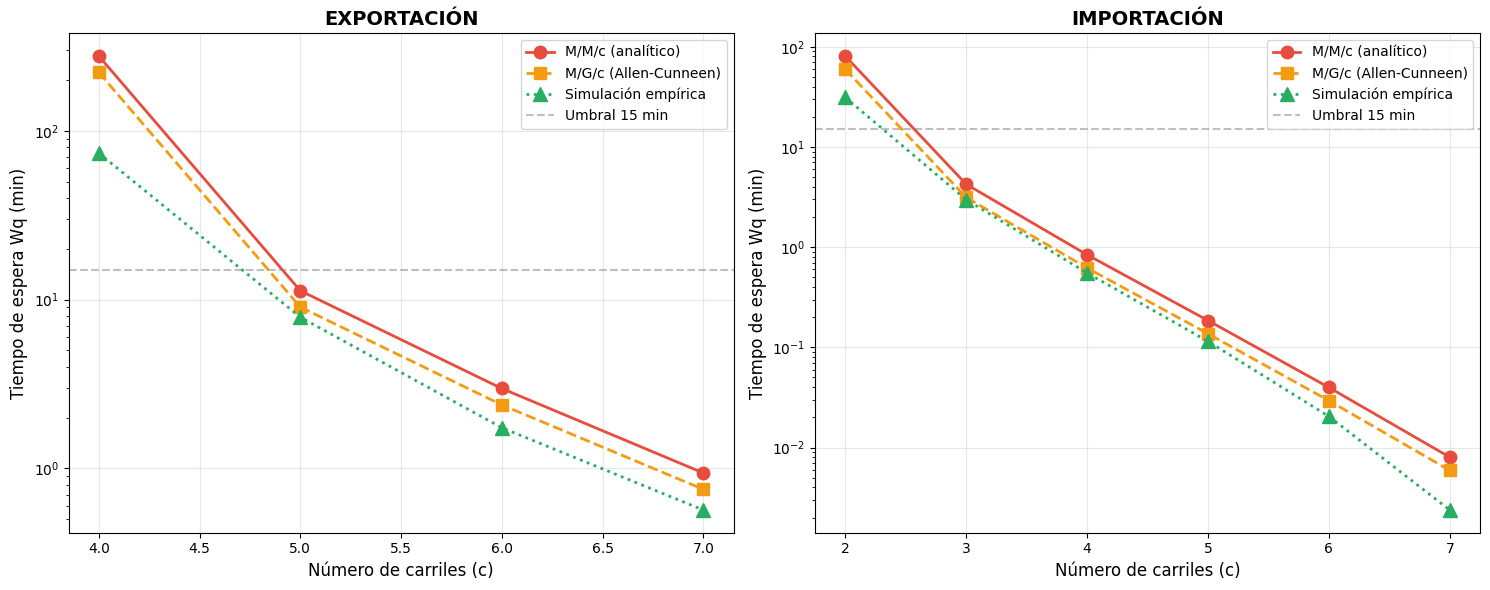

✅ Gráfico guardado en tu Drive


In [ ]:
import matplotlib.pyplot as plt
import numpy as np

fig, axes = plt.subplots(1, 2, figsize=(15, 6))

for ax, (df, nombre) in zip(axes, [(exp_clean, 'EXPORTACIÓN'), (imp_clean, 'IMPORTACIÓN')]):
    tiempos = df['T_Servicio_min'].dropna()
    tiempos = tiempos[tiempos > 0].values
    lam, mu = calcular_parametros(df)
    cv_s = tiempos.std() / tiempos.mean()

    cs, wq_mmc, wq_mgc, wq_sim = [], [], [], []
    for c in range(1, 8):
        if lam / (c * mu) >= 1:
            continue
        cs.append(c)
        wq_mmc.append(metricas_analiticas(lam, mu, c)['Wq_min'])
        wq_mgc.append(metricas_mgc(lam, mu, c, cv_s)['Wq_min'])
        wq_sim.append(simular_empirico(lam, tiempos, c, n_camiones=2000)['Wq_min'])

    ax.plot(cs, wq_mmc, 'o-',  label='M/M/c (analítico)',  color='#e74c3c', linewidth=2, markersize=9)
    ax.plot(cs, wq_mgc, 's--', label='M/G/c (Allen-Cunneen)', color='#f39c12', linewidth=2, markersize=9)
    ax.plot(cs, wq_sim, '^:',  label='Simulación empírica', color='#27ae60', linewidth=2, markersize=10)

    ax.axhline(y=15, color='gray', linestyle='--', alpha=0.5, label='Umbral 15 min')
    ax.set_xlabel('Número de carriles (c)', fontsize=12)
    ax.set_ylabel('Tiempo de espera Wq (min)', fontsize=12)
    ax.set_title(f'{nombre}', fontsize=14, fontweight='bold')
    ax.legend(fontsize=10)
    ax.grid(alpha=0.3)
    ax.set_yscale('log')  # escala logarítmica por los valores grandes

plt.tight_layout()
plt.savefig('/content/drive/MyDrive/Tesis/comparacion_modelos.png', dpi=200, bbox_inches='tight')
plt.show()
print("✅ Gráfico guardado en tu Drive")

In [ ]:
# Tabla resumen exportable
resumen = []

for df, nombre in [(exp_clean, 'Exportación'), (imp_clean, 'Importación')]:
    tiempos = df['T_Servicio_min'].dropna()
    tiempos = tiempos[tiempos > 0].values
    lam, mu = calcular_parametros(df)
    cv_s = tiempos.std() / tiempos.mean()

    for c in range(1, 8):
        rho = lam / (c * mu)
        if rho >= 1:
            resumen.append({
                'Proceso': nombre, 'Carriles': c,
                'ρ (%)': round(rho*100, 1),
                'Wq M/M/c (min)': 'INESTABLE',
                'Wq M/G/c (min)': 'INESTABLE',
                'Wq Simulación (min)': 'INESTABLE',
                'W total sim (min)': 'INESTABLE',
                'Estado': 'INESTABLE'
            })
        else:
            r_mmc = metricas_analiticas(lam, mu, c)
            r_mgc = metricas_mgc(lam, mu, c, cv_s)
            r_sim = simular_empirico(lam, tiempos, c, n_camiones=2000)
            resumen.append({
                'Proceso': nombre, 'Carriles': c,
                'ρ (%)': round(rho*100, 1),
                'Wq M/M/c (min)': round(r_mmc['Wq_min'], 2),
                'Wq M/G/c (min)': round(r_mgc['Wq_min'], 2),
                'Wq Simulación (min)': round(r_sim['Wq_min'], 2),
                'W total sim (min)': round(r_sim['W_min'], 2),
                'Estado': 'OK' if rho < 0.85 else 'SATURADO'
            })

df_resumen = pd.DataFrame(resumen)
df_resumen.to_excel('/content/drive/MyDrive/Tesis/tabla_resumen_teoria_colas.xlsx', index=False)
print("✅ Tabla guardada en tu Drive")
df_resumen


✅ Tabla guardada en tu Drive


,Proceso,Carriles,ρ (%),Wq M/M/c (min),Wq M/G/c (min),Wq Simulación (min),W total sim (min),Estado
0,Exportación,1,392.0,INESTABLE,INESTABLE,INESTABLE,INESTABLE,INESTABLE
1,Exportación,2,196.0,INESTABLE,INESTABLE,INESTABLE,INESTABLE,INESTABLE
2,Exportación,3,130.7,INESTABLE,INESTABLE,INESTABLE,INESTABLE,INESTABLE
3,Exportación,4,98.0,277.68,222.03,73.85,96.96,SATURADO
4,Exportación,5,78.4,11.29,9.03,7.87,30.97,OK
5,Exportación,6,65.3,2.97,2.38,1.74,24.84,OK
6,Exportación,7,56.0,0.94,0.75,0.57,23.67,OK
7,Importación,1,185.9,INESTABLE,INESTABLE,INESTABLE,INESTABLE,INESTABLE
8,Importación,2,92.9,80.83,59.66,31.3,43.58,SATURADO
9,Importación,3,62.0,4.25,3.13,2.98,15.26,OK


ANÁLISIS POR FRANJA HORARIA

In [ ]:
# Análisis por hora del día
for df, nombre in [(exp_clean, 'EXPORTACIÓN'), (imp_clean, 'IMPORTACIÓN')]:
    df['hora'] = pd.to_datetime(df['T. Llegada'].astype(str),
                                 format='%H:%M:%S', errors='coerce').dt.hour

    print(f"\n=== {nombre} - Distribución por hora ===")
    conteo = df.groupby('hora').size()
    lam_hora = conteo / df.groupby('hora')['Fecha_dt'].nunique().reindex(conteo.index)
    for h in conteo.index:
        print(f"  {h:02d}h: {conteo[h]:3d} camiones | λ={lam_hora[h]:.2f} cam/h")


=== EXPORTACIÓN - Distribución por hora ===
  14h:   7 camiones | λ=7.00 cam/h
  15h:  31 camiones | λ=6.20 cam/h
  16h:  38 camiones | λ=9.50 cam/h
  17h:  37 camiones | λ=7.40 cam/h
  18h:  28 camiones | λ=9.33 cam/h
  19h:  11 camiones | λ=3.67 cam/h
  20h:   1 camiones | λ=1.00 cam/h

=== IMPORTACIÓN - Distribución por hora ===
  15h:  10 camiones | λ=2.50 cam/h
  16h:  47 camiones | λ=9.40 cam/h
  17h:  12 camiones | λ=3.00 cam/h
  18h:  26 camiones | λ=8.67 cam/h
  19h:  11 camiones | λ=3.67 cam/h


ANÁLISIS DE SENSIBILIDAD

In [ ]:
print("=== SENSIBILIDAD: ¿Qué pasa si λ crece 20%? ===")
for df, nombre in [(exp_clean, 'EXPORTACIÓN'), (imp_clean, 'IMPORTACIÓN')]:
    lam, mu = calcular_parametros(df)
    lam_futuro = lam * 1.2
    print(f"\n{nombre}: λ_actual={lam:.2f} → λ_futuro={lam_futuro:.2f}")
    for c in range(1, 9):
        rho = lam_futuro / (c * mu)
        if rho < 1:
            print(f"  c={c}: ρ={rho:.1%}")

=== SENSIBILIDAD: ¿Qué pasa si λ crece 20%? ===

EXPORTACIÓN: λ_actual=10.10 → λ_futuro=12.11
  c=5: ρ=94.1%
  c=6: ρ=78.4%
  c=7: ρ=67.2%
  c=8: ρ=58.8%

IMPORTACIÓN: λ_actual=8.75 → λ_futuro=10.50
  c=3: ρ=74.4%
  c=4: ρ=55.8%
  c=5: ρ=44.6%
  c=6: ρ=37.2%
  c=7: ρ=31.9%
  c=8: ρ=27.9%
